# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. 
# All work submitted is my own and reflects my understanding of the material.

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [9]:
g = 9.81
L = 1.0

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [10]:
def pendulum(t, y):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -(g / L) * np.sin(theta)
    return[dtheta_dt, domega_dt]

Give your equation some initial conditions. Run the cell below.

In [11]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [12]:
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval = t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

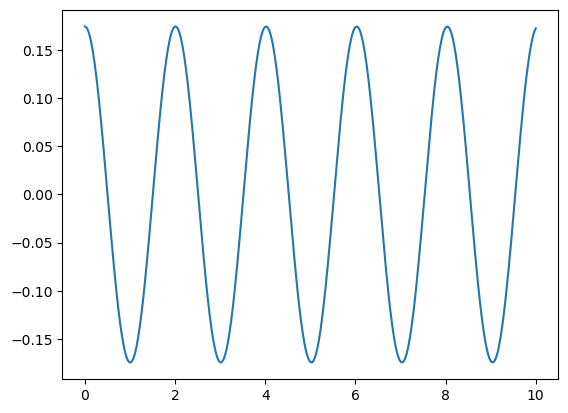

In [13]:
theta_values = sol.y[0]
time_values = sol.t

plt.plot(time_values, theta_values)

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [17]:
# Compute the theoretical period using the small-angle approximation
T = 2 * np.pi * np.sqrt(L / g)

# Output
print(f"theoretical period of the pendulum is {T} seconds.")

theoretical period of the pendulum is 2.0060666807106475 seconds.


Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [20]:
print(f"theoretical period of the pendulum is {T:.2g} seconds.")

theoretical period of the pendulum is 2 seconds.


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [24]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

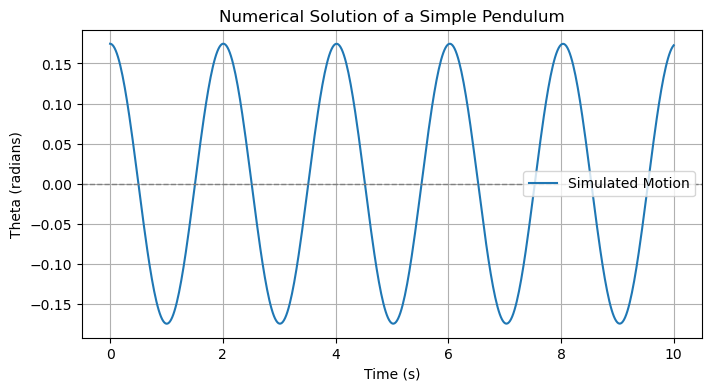

In [26]:
# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(time_values, theta_values, label="Simulated Motion")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Horizontal line at x=0
plt.xlabel("Time (s)")
plt.ylabel("Theta (radians)")
plt.title("Numerical Solution of a Simple Pendulum")
plt.legend()
plt.grid()
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [27]:
print(f"estimated period from simulation: {T_numerical:.4g} seconds")

estimated period from simulation: 2.004 seconds


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [28]:
# The small-angle approximation is more accurate for small initial angles.
# But, for larger angles, the approximation underestimates the actual period. 
# I think this happens bc it doesnt account for non-linearity.

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [29]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [32]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [34]:
df = pd.read_csv("owid-covid-data.csv")

print(df.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [36]:
# Filter for United States
df_country = df[df["location"] == "United States"]

print(df_country.head())

       iso_code      continent       location        date  total_cases  \
403451      USA  North America  United States  2020-01-05          0.0   
403452      USA  North America  United States  2020-01-06          0.0   
403453      USA  North America  United States  2020-01-07          0.0   
403454      USA  North America  United States  2020-01-08          0.0   
403455      USA  North America  United States  2020-01-09          0.0   

        new_cases  new_cases_smoothed  total_deaths  new_deaths  \
403451        0.0                 NaN           0.0         0.0   
403452        0.0                 NaN           0.0         0.0   
403453        0.0                 NaN           0.0         0.0   
403454        0.0                 NaN           0.0         0.0   
403455        0.0                 NaN           0.0         0.0   

        new_deaths_smoothed  ...  male_smokers  handwashing_facilities  \
403451                  NaN  ...          24.6                     NaN   
4034

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [38]:
# Extract relevant columns and drop rows with missing values
df_country_relevant = df_country[["date", "total_cases"]].dropna()

# Add a new column "days since start", starting from 0
df_country_relevant["days_since_start"] = range(len(df_country_relevant))

Print the first few rows of your `df_country` dataframe.

In [39]:
# Display the first few rows
print(df_country_relevant.head())

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [40]:
import numpy as np
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [41]:
import numpy as np

def exponential_growth(t, C_0, r):
    return C_0 * np.exp(r * t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [42]:
days = df_country_relevant["days_since_start"][:30]
cases = df_country_relevant["total_cases"][:30]

print(days)
print(cases)

403451     0
403452     1
403453     2
403454     3
403455     4
403456     5
403457     6
403458     7
403459     8
403460     9
403461    10
403462    11
403463    12
403464    13
403465    14
403466    15
403467    16
403468    17
403469    18
403470    19
403471    20
403472    21
403473    22
403474    23
403475    24
403476    25
403477    26
403478    27
403479    28
403480    29
Name: days_since_start, dtype: int64
403451    0.0
403452    0.0
403453    0.0
403454    0.0
403455    0.0
403456    0.0
403457    0.0
403458    0.0
403459    0.0
403460    0.0
403461    0.0
403462    0.0
403463    0.0
403464    0.0
403465    0.0
403466    0.0
403467    0.0
403468    0.0
403469    0.0
403470    0.0
403471    0.0
403472    7.0
403473    7.0
403474    7.0
403475    7.0
403476    7.0
403477    7.0
403478    7.0
403479    9.0
403480    9.0
Name: total_cases, dtype: float64


With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [43]:
# Fit the model to the data
params, covariance = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])

# Extract the fitted parameters
C_0_fit, r_fit = params

# Print the fitted parameters
print(f"Fitted initial number of cases (C_0): {C_0_fit:.4f}")
print(f"Fitted growth rate (r): {r_fit:.4f}")

Fitted initial number of cases (C_0): 0.1239
Fitted growth rate (r): 0.1538


Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [44]:
# Fit the model to the data
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])

# Extract the best-fit parameters
C0_fit, r_fit = popt

# Print
print(f"Fitted initial number of cases (C_0): {C0_fit:.4f}")
print(f"Fitted growth rate (r): {r_fit:.4f}")

Fitted initial number of cases (C_0): 0.1239
Fitted growth rate (r): 0.1538


Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [46]:
print(f"Fitted initial number of cases (C_0): {C0_fit:.2g}")
print(f"Fitted growth rate (r): {r_fit:.4g}")

Fitted initial number of cases (C_0): 0.12
Fitted growth rate (r): 0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [47]:
import matplotlib.pyplot as plt
import numpy as np

future_days = np.arange(0, 61)  # Predicting for 0 to 60 days
print(future_days)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60]


Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [48]:
predicted_cases = exponential_growth(future_days, *popt)

# Print the predicted cases
print(predicted_cases)

[1.23895309e-01 1.44499984e-01 1.68531364e-01 1.96559334e-01
 2.29248556e-01 2.67374228e-01 3.11840473e-01 3.63701772e-01
 4.24187975e-01 4.94733465e-01 5.77011175e-01 6.72972256e-01
 7.84892351e-01 9.15425556e-01 1.06766737e+00 1.24522808e+00
 1.45231840e+00 1.69384933e+00 1.97554858e+00 2.30409642e+00
 2.68728411e+00 3.13419866e+00 3.65543829e+00 4.26336380e+00
 4.97239165e+00 5.79933591e+00 6.76380691e+00 7.88867632e+00
 9.20061955e+00 1.07307483e+01 1.25153484e+01 1.45967403e+01
 1.70242825e+01 1.98555423e+01 2.31576608e+01 2.70089453e+01
 3.15007259e+01 3.67395216e+01 4.28495666e+01 4.99757556e+01
 5.82870808e+01 6.79806388e+01 7.92863048e+01 9.24721837e+01
 1.07850969e+02 1.25787355e+02 1.46706691e+02 1.71105062e+02
 1.99561056e+02 2.32749485e+02 2.71457388e+02 3.16602691e+02
 3.69255980e+02 4.30665888e+02 5.02288702e+02 5.85822902e+02
 6.83249436e+02 7.96878699e+02 9.29405320e+02 1.08397206e+03
 1.26424436e+03]


**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

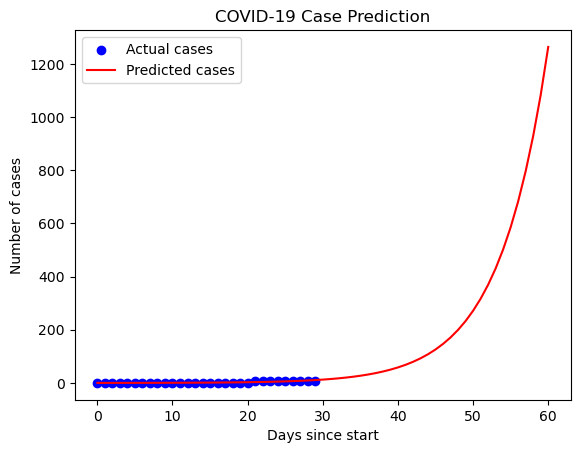

In [49]:
plt.scatter(days, cases, color='blue', label='Actual cases')
plt.plot(future_days, predicted_cases, color='red', label='Predicted cases')

plt.xlabel('Days since start')
plt.ylabel('Number of cases')
plt.title('COVID-19 Case Prediction')
plt.legend()
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [ ]:
# Pretty good at the beginning but like the data doesnt exponentiate that fast.
# So, like we don't really know just how much it really curves up.
# but for the beginning of the data it fits really well

Make another plot but this time to **90 days**.

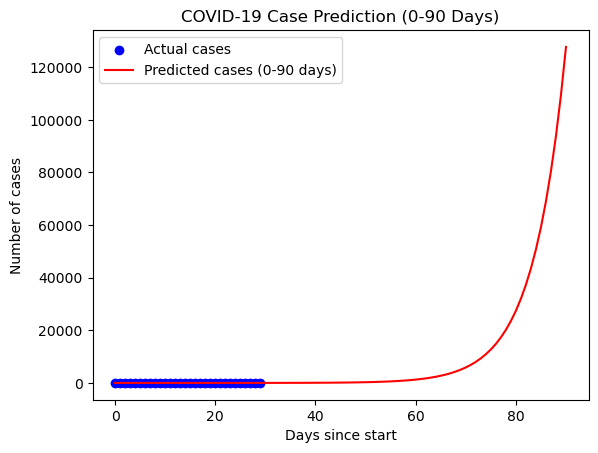

In [50]:
# Update future_days to predict up to 90 days
future_days_90 = np.arange(0, 91)
predicted_cases_90 = exponential_growth(future_days_90, *popt)
plt.scatter(days, cases, color='blue', label='Actual cases')

# Plot the predicted cases as a function of future_days_90
plt.plot(future_days_90, predicted_cases_90, color='red', label='Predicted cases (0-90 days)')
plt.xlabel('Days since start')
plt.ylabel('Number of cases')
plt.title('COVID-19 Case Prediction (0-90 Days)')
plt.legend()
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [51]:
# About 70,000

## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


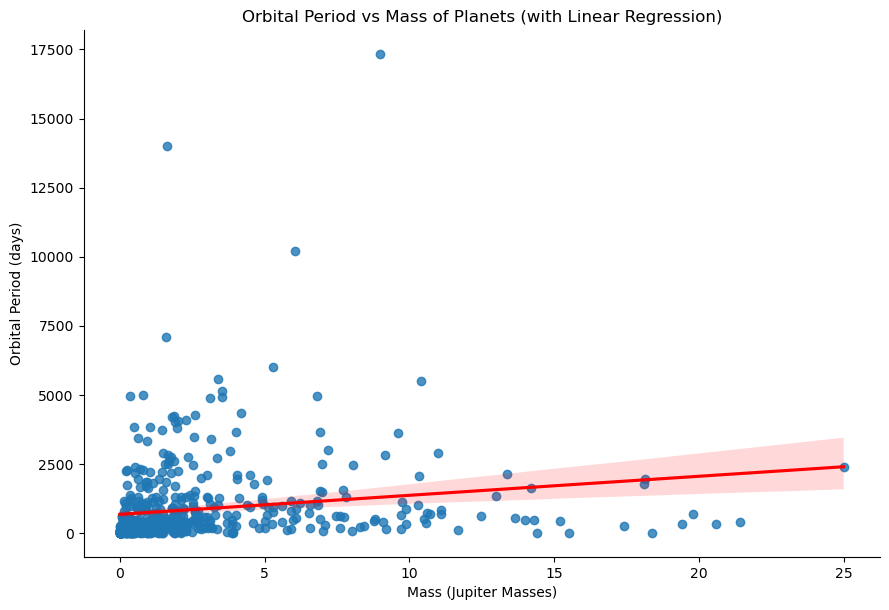

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the 'planets' dataset from Seaborn (similar to loading from a CSV)
data = sns.load_dataset('planets')

# Display the first few rows of the dataset
print(data.head())

# Create a scatter plot with a linear regression line
sns.lmplot(x='mass', y='orbital_period', data=data, aspect=1.5, height=6, line_kws={'color': 'red'})

# Add labels and a title
plt.xlabel('Mass (Jupiter Masses)')
plt.ylabel('Orbital Period (days)')
plt.title('Orbital Period vs Mass of Planets (with Linear Regression)')

# Display the plot
plt.show()

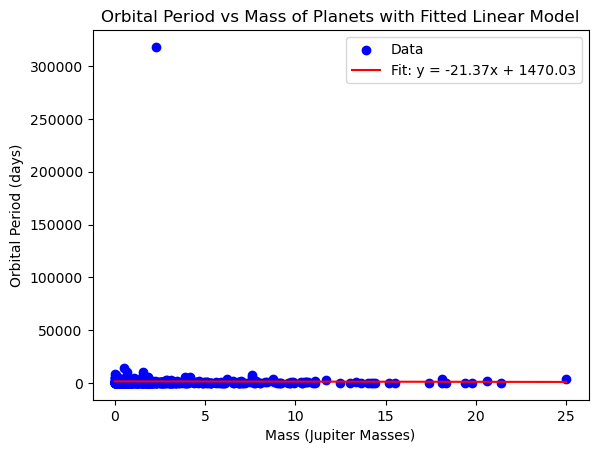

In [57]:
def linear_model(x, a, b):
    return a * x + b

# Extract data for fitting, and drop NaN values
x_data = data['mass'].dropna()  # Remove NaN values from 'mass'
y_data = data['orbital_period'].dropna()  # Remove NaN values from 'orbital_period'

# Ensure that the lengths of x_data and y_data are the same after dropping NaNs
min_length = min(len(x_data), len(y_data))
x_data = x_data.iloc[:min_length]
y_data = y_data.iloc[:min_length]

# Fit the linear model to the data
popt, pcov = curve_fit(linear_model, x_data, y_data)
a_fit, b_fit = popt

# Generate the fitted line
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = linear_model(x_fit, *popt)

# Create the plot
plt.scatter(x_data, y_data, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {a_fit:.2f}x + {b_fit:.2f}')

# Add labels and a title
plt.xlabel('Mass (Jupiter Masses)')
plt.ylabel('Orbital Period (days)')
plt.title('Orbital Period vs Mass of Planets with Fitted Linear Model')
plt.legend()
plt.show()

On it's own branch, submit this notebook to Gradescope! 